In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report

# CONFIG
VAL_DIR      = "/content/drive/MyDrive/Annotations/val"
PRED_PATH    = "/content/drive/MyDrive/Models/timesformer-cows2/ts_y_pred.npy"
RB_THRESHOLD = 2.0    # below = IR nighttime, above = daytime with barn lights
N_FRAMES     = 5      # frames to sample per clip for classification

CLASSES = [
    "Drinking", "Feeding & Lying", "Feeding & Standing", "Lying",
    "Ruminating & Lying", "Ruminating & Standing", "Standing",
]
label2id = {c: i for i, c in enumerate(CLASSES)}

# BUILD VAL ITEMS
val_items = []
for cls in CLASSES:
    cls_dir = os.path.join(VAL_DIR, cls)
    files = sorted([f for f in os.listdir(cls_dir)
                    if f.endswith(('.mp4','.MP4','.mkv','.MOV','.mov'))])
    for f in files:
        val_items.append((os.path.join(cls_dir, f), label2id[cls], cls))

print(f"Total val clips: {len(val_items)}")

#CLASSIFY EACH CLIP
def get_rb_diff(clip_path, n_frames=N_FRAMES):
    cap = cv2.VideoCapture(clip_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release()
        return None
    rb_diffs = []
    for fi in np.linspace(0, total-1, n_frames).astype(int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if not ret:
            continue
        b = frame[:,:,0].astype(float)
        r = frame[:,:,2].astype(float)
        rb_diffs.append(np.mean(np.abs(r - b)))
    cap.release()
    return np.mean(rb_diffs) if rb_diffs else None

print("Classifying clips (this takes a few minutes)...")
conditions = []
rb_values  = []

for i, (path, label, cls) in enumerate(val_items):
    rb = get_rb_diff(path)
    rb_values.append(rb)
    if rb is None:
        conditions.append("unknown")
    elif rb > RB_THRESHOLD:
        conditions.append("daytime")
    else:
        conditions.append("nighttime")

    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(val_items)} done...")


ts_pred = np.load(PRED_PATH)
y_true  = np.array([label for _, label, _ in val_items])

overall_acc = accuracy_score(y_true, ts_pred)
print(f"\nOverall accuracy check: {overall_acc:.4f} (expect ~0.855)")

#  BUILD RESULTS
df = pd.DataFrame({
    "clip_path":   [p for p,_,_ in val_items],
    "class_label": [c for _,_,c in val_items],
    "rb_diff":     rb_values,
    "condition":   conditions,
    "y_true":      y_true,
    "y_pred":      ts_pred,
})

print(f"\nCondition distribution:")
print(df["condition"].value_counts())
print(f"\nRB diff stats:")
print(f"  Daytime:   {df[df['condition']=='daytime']['rb_diff'].describe()}")
print(f"  Nighttime: {df[df['condition']=='nighttime']['rb_diff'].describe()}")

df.to_csv("val_day_night_rb.csv", index=False)
print("\nSaved → val_day_night_rb.csv")

# EVALUATE BY CONDITION
print("\n" + "="*60)
print("RESULTS — from same 1,119-clip held-out val set")
print("Directly comparable to overall 85.8% result")
print("="*60)

for condition in ["daytime", "nighttime"]:
    subset = df[df["condition"] == condition]
    if len(subset) == 0:
        print(f"\nNo {condition} clips found")
        continue

    yt = subset["y_true"].values
    yp = subset["y_pred"].values

    acc = accuracy_score(yt, yp)
    f1  = f1_score(yt, yp, average="macro", zero_division=0)

    print(f"\n{condition.upper()} — n={len(subset)} clips")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.1f}%)")
    print(f"  Macro-F1: {f1:.4f}")
    print(classification_report(yt, yp, target_names=CLASSES,
                                 labels=list(range(len(CLASSES))),
                                 digits=3, zero_division=0))

#  SUMMARY
print("="*60)
print("SUMMARY")
print("="*60)
for cond in ["daytime", "nighttime"]:
    sub = df[df["condition"]==cond]
    if len(sub) > 0:
        acc = accuracy_score(sub["y_true"], sub["y_pred"])
        f1  = f1_score(sub["y_true"], sub["y_pred"],
                       average="macro", zero_division=0)
        print(f"{cond:<12} n={len(sub):>4}  "
              f"acc={acc*100:.1f}%  macro-F1={f1:.3f}")
print(f"{'Overall':<12} n={len(df):>4}  "
      f"acc={overall_acc*100:.1f}%  macro-F1="
      f"{f1_score(y_true, ts_pred, average='macro'):.3f}")
print("\nAll values from same 1,119-clip val set — directly comparable.")

Total val clips: 1119
Classifying clips (this takes a few minutes)...
  100/1119 done...
  200/1119 done...
  300/1119 done...
  400/1119 done...
  500/1119 done...
  600/1119 done...
  700/1119 done...
  800/1119 done...
  900/1119 done...
  1000/1119 done...
  1100/1119 done...

Overall accuracy check: 0.8552 (expect ~0.855)

Condition distribution:
condition
daytime      670
nighttime    449
Name: count, dtype: int64

RB diff stats:
  Daytime:   count    670.000000
mean       5.991022
std        2.215097
min        2.060019
25%        4.382296
50%        5.654120
75%        7.249457
max       13.860700
Name: rb_diff, dtype: float64
  Nighttime: count    449.000000
mean       0.387746
std        0.228540
min        0.116104
25%        0.273989
50%        0.359172
75%        0.430471
max        1.875954
Name: rb_diff, dtype: float64

Saved → val_day_night_rb.csv

RESULTS — from same 1,119-clip held-out val set
Directly comparable to overall 85.8% result

DAYTIME — n=670 clips
  Accura

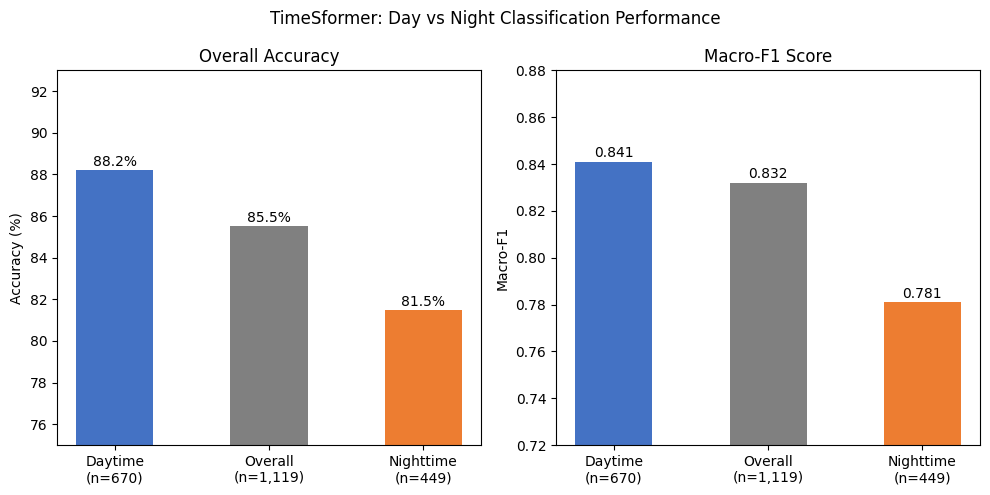

In [2]:
import matplotlib.pyplot as plt
import numpy as np

conditions = ["Daytime\n(n=670)", "Overall\n(n=1,119)", "Nighttime\n(n=449)"]
accuracy   = [88.2, 85.5, 81.5]
macro_f1   = [0.841, 0.832, 0.781]
colours    = ["#4472C4", "#808080", "#ED7D31"]
x          = np.arange(3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Accuracy
ax1.bar(x, accuracy, color=colours, width=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(conditions)
ax1.set_ylabel("Accuracy (%)")
ax1.set_ylim(75, 93)
ax1.set_title("Overall Accuracy")
for i, v in enumerate(accuracy):
    ax1.text(i, v + 0.2, f"{v:.1f}%", ha="center")

# Macro-F1
ax2.bar(x, macro_f1, color=colours, width=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(conditions)
ax2.set_ylabel("Macro-F1")
ax2.set_ylim(0.72, 0.88)
ax2.set_title("Macro-F1 Score")
for i, v in enumerate(macro_f1):
    ax2.text(i, v + 0.002, f"{v:.3f}", ha="center")

plt.suptitle("TimeSformer: Day vs Night Classification Performance")
plt.tight_layout()
plt.savefig("robustness.png", dpi=300, bbox_inches="tight")
plt.show()